In [1]:
!pip install -q torch torchvision matplotlib pillow numpy tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

os.makedirs("outputs/cgan", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

SHAPE_LABELS = {
    0: "circle",
    1: "square",
    2: "triangle",
    3: "star",
    4: "hexagon"
}
print("Shape labels:", SHAPE_LABELS)

Using device: cuda
Shape labels: {0: 'circle', 1: 'square', 2: 'triangle', 3: 'star', 4: 'hexagon'}


In [3]:
def generate_shape_image(label_idx, size=64):
    img = Image.new("RGB", (size, size), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    margin = size // 8
    color = (255, 255, 255)

    if label_idx == 0:  # circle
        draw.ellipse([margin, margin, size-margin, size-margin], fill=color)
    elif label_idx == 1:  # square
        draw.rectangle([margin, margin, size-margin, size-margin], fill=color)
    elif label_idx == 2:  # triangle
        draw.polygon([(size//2, margin), (size-margin, size-margin), (margin, size-margin)], fill=color)
    elif label_idx == 3:  # star
        cx, cy = size//2, size//2
        r_out, r_in = size//2 - margin, size//5
        pts = []
        for i in range(5):
            a = np.deg2rad(90 + i*72)
            pts.append((cx + r_out*np.cos(a), cy - r_out*np.sin(a)))
            a2 = np.deg2rad(90 + i*72 + 36)
            pts.append((cx + r_in*np.cos(a2), cy - r_in*np.sin(a2)))
        draw.polygon(pts, fill=color)
    else:  # hexagon
        cx, cy = size//2, size//2
        r = size//2 - margin
        pts = [(cx + r*np.cos(np.deg2rad(60*i)), cy + r*np.sin(np.deg2rad(60*i))) for i in range(6)]
        draw.polygon(pts, fill=color)

    arr = np.array(img).astype(np.float32) / 255.0
    arr = (arr - 0.5) / 0.5  # scale to [-1, 1]
    return arr.transpose(2, 0, 1)  # C, H, W

In [4]:
def make_dataset(n_per_class=250, size=64):
    images, labels = [], []
    for idx in range(len(SHAPE_LABELS)):
        for _ in range(n_per_class):
            img = generate_shape_image(idx, size)
            noise = np.random.normal(0, 0.05, img.shape).astype(np.float32)
            img = np.clip(img + noise, -1, 1)
            images.append(img)
            labels.append(idx)
    images = torch.tensor(np.stack(images), dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)
    return TensorDataset(images, labels)

dataset = make_dataset()
print("Dataset size:", len(dataset))

Dataset size: 1250


In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, embed_dim=50, n_classes=5):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(z_dim + embed_dim, 256*4*4),
            nn.BatchNorm1d(256*4*4),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        emb = self.label_emb(labels)
        x = torch.cat([z, emb], dim=1)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, embed_dim=50, n_classes=5):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, embed_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(256*4*4 + embed_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1)
        )

    def forward(self, img, labels):
        emb = self.label_emb(labels)
        feat = self.conv(img)
        x = torch.cat([feat, emb], dim=1)
        return self.fc(x)

G = Generator().to(device)
D = Discriminator().to(device)
print("Generator and Discriminator created")

Generator and Discriminator created


In [7]:
z_dim = 100
lr = 0.0002
epochs = 100
batch_size = 64

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

fixed_z = torch.randn(20, z_dim, device=device)
fixed_labels = torch.arange(5, device=device).repeat_interleave(4)

for epoch in range(1, epochs+1):
    d_losses, g_losses = [], []
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}")
    for real_imgs, real_labels in pbar:
        real_imgs, real_labels = real_imgs.to(device), real_labels.to(device)
        B = real_imgs.size(0)

        # Train Discriminator
        opt_D.zero_grad()
        real_pred = D(real_imgs, real_labels)
        real_loss = criterion(real_pred, torch.ones_like(real_pred))

        z = torch.randn(B, z_dim, device=device)
        fake_labels = torch.randint(0, 5, (B,), device=device)
        fake_imgs = G(z, fake_labels).detach()
        fake_pred = D(fake_imgs, fake_labels)
        fake_loss = criterion(fake_pred, torch.zeros_like(fake_pred))

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        opt_D.step()

        # Train Generator
        opt_G.zero_grad()
        z = torch.randn(B, z_dim, device=device)
        gen_labels = torch.randint(0, 5, (B,), device=device)
        gen_imgs = G(z, gen_labels)
        gen_pred = D(gen_imgs, gen_labels)
        g_loss = criterion(gen_pred, torch.ones_like(gen_pred))
        g_loss.backward()
        opt_G.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())
        pbar.set_postfix(D=f"{d_loss.item():.3f}", G=f"{g_loss.item():.3f}")

    print(f"Epoch {epoch}: D_loss={np.mean(d_losses):.3f} | G_loss={np.mean(g_losses):.3f}")

# Save the trained generator
torch.save(G.state_dict(), "outputs/cgan/generator.pt")
print("Generator saved → outputs/cgan/generator.pt")

Epoch 1/100: 100%|██████████| 19/19 [00:00<00:00, 29.78it/s, D=0.000, G=11.410]


Epoch 1: D_loss=0.001 | G_loss=13.410


Epoch 2/100: 100%|██████████| 19/19 [00:00<00:00, 36.06it/s, D=10.129, G=0.008]


Epoch 2: D_loss=0.533 | G_loss=12.124


Epoch 3/100: 100%|██████████| 19/19 [00:00<00:00, 35.97it/s, D=0.035, G=5.280]


...

Epoch 98: D_loss=0.028 | G_loss=4.676


Epoch 99/100: 100%|██████████| 19/19 [00:00<00:00, 33.22it/s, D=0.009, G=5.207]


Epoch 99: D_loss=0.038 | G_loss=4.695


Epoch 100/100: 100%|██████████| 19/19 [00:00<00:00, 33.43it/s, D=0.040, G=4.723]

Epoch 100: D_loss=0.030 | G_loss=4.958
Generator saved → outputs/cgan/generator.pt


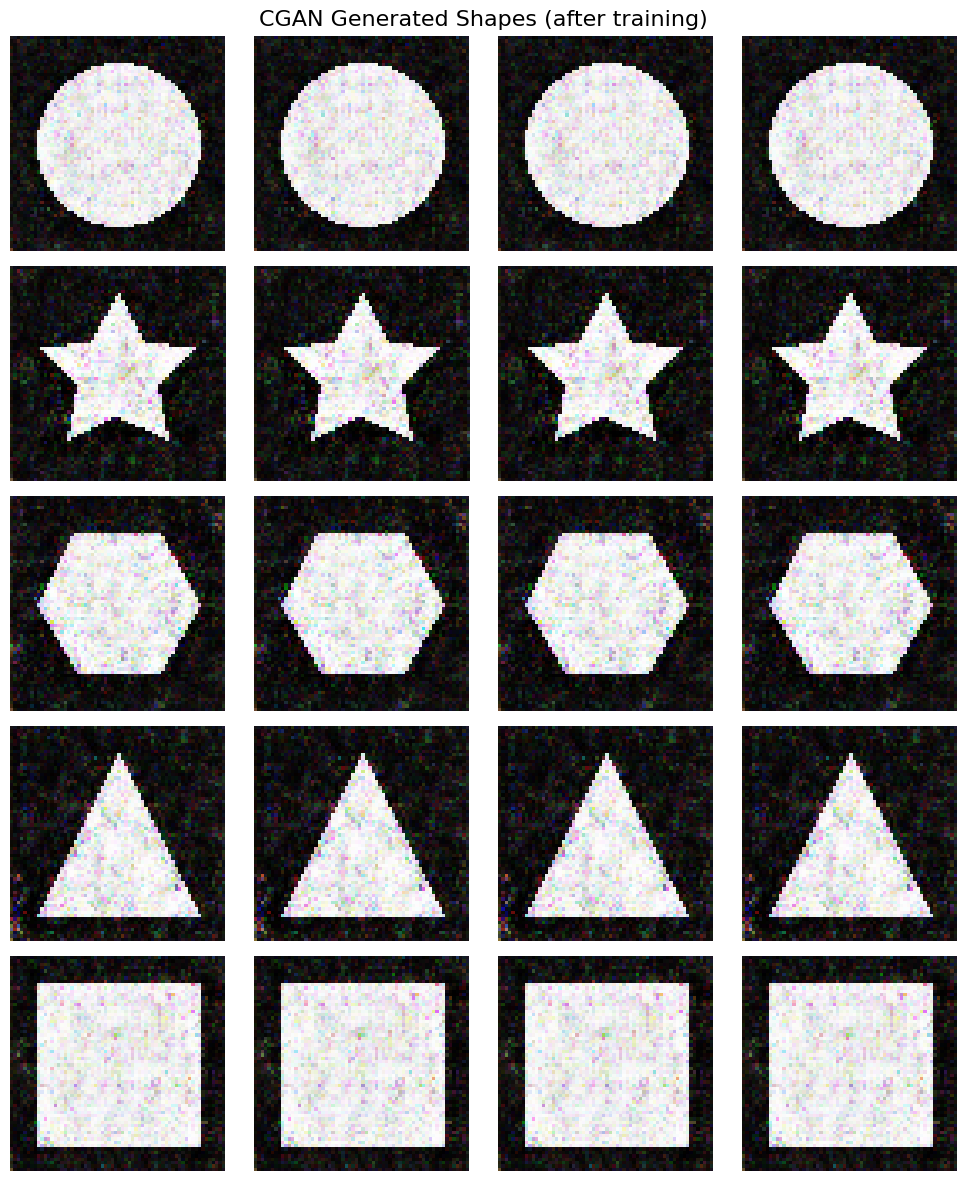

Saved → outputs/cgan/final_shapes.png


In [8]:
G.eval()
with torch.no_grad():
    samples = G(fixed_z, fixed_labels)
    samples = (samples.clamp(-1, 1) + 1) / 2  # back to [0,1]

fig, axes = plt.subplots(5, 4, figsize=(10, 12))
for i in range(5):
    for j in range(4):
        idx = i*4 + j
        img = samples[idx].cpu().permute(1, 2, 0).numpy()
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(SHAPE_LABELS[i], rotation=0, labelpad=40, fontsize=12)

plt.suptitle("CGAN Generated Shapes (after training)", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/cgan/final_shapes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → outputs/cgan/final_shapes.png")

MY OBSERVATIONS:

1. Random noise and a class label (condition) are both input to the Generator.
2. The Discriminator also gets the label so that it can see if the picture is the same as the class label.
3. Following training the model yields various shapes for various labels.
4. This is the main concept of Conditional GANs: to use additional information (text/label) to control the output.
5. Now we will enhance this with attention and link it with the real text embeddings.